# 03 · Training and evaluating the model

**Supports agenda block 7** ("Training & Evaluating the Model"). LightGBM
with walk-forward cross-validation - never a random shuffle-split, which
would train on the future and validate on the past - and the
**Information Coefficient (IC)**, HAC-corrected for the autocorrelation
that a 21-day-overlapping label mechanically introduces, as the metric
that actually says whether the model found anything.

In [1]:
import os
import subprocess
import sys
from pathlib import Path


def run_notebook(name):
    """Execute a prerequisite notebook in place of a missing derived data file.

    The derived parquet files are gitignored, so a fresh clone that opens this notebook
    first has to build them. Running the .ipynb keeps the notebook the only source of
    truth; an exported .py alongside it would be a second copy free to drift.
    """
    subprocess.run(
        [
            sys.executable,
            "-m",
            "jupyter",
            "nbconvert",
            "--to",
            "notebook",
            "--execute",
            "--output-dir",
            "/tmp",
            name,
        ],
        check=True,
    )


if "COLAB_RELEASE_TAG" in os.environ:
    repo_dir = Path(os.environ.get("PACKT_WORKSHOP_DIR", "/content/packt-workshop"))
    if not repo_dir.exists():
        subprocess.run(
            [
                "git",
                "clone",
                "--depth",
                "1",
                "https://github.com/ml4t/packt-workshop.git",
                repo_dir,
            ],
            check=True,
        )
    ready = repo_dir.parent / ".packt-workshop-ready"
    if not ready.exists():
        # Colab's kernel already has numpy imported before this cell runs. Installing a
        # different numpy from requirements-colab.txt overwrites the files on disk but not
        # the compiled submodules already cached in this process, so importing a numpy
        # submodule for the first time later (e.g. via ml4t.engineer) mixes the new files
        # with the stale cached extension and raises ImportError. Put numpy back to the
        # version this process already has loaded once the rest of the install is done.
        import numpy as _colab_numpy

        colab_numpy_version = _colab_numpy.__version__
        subprocess.run(
            [
                sys.executable,
                "-m",
                "pip",
                "install",
                "-q",
                "-r",
                repo_dir / "requirements-colab.txt",
            ],
            check=True,
        )
        subprocess.run(
            [
                sys.executable,
                "-m",
                "pip",
                "install",
                "-q",
                "--force-reinstall",
                "--no-deps",
                f"numpy=={colab_numpy_version}",
            ],
            check=True,
        )
        ready.touch()
    os.chdir(repo_dir / "notebooks")
    if not (repo_dir / "data/model_dataset.parquet").exists():
        print("Preparing the feature-and-label dataset required by this notebook.")
        run_notebook("02_features_labels.ipynb")

In [2]:
import lightgbm as lgb
import pandas as pd
from ml4t.diagnostic.metrics import compute_ic_hac_stats, cross_sectional_ic_series
from ml4t.diagnostic.splitters import WalkForwardConfig, WalkForwardCV

DATA_DIR = "../data"
LABEL_HORIZON = 21  # trading days - must match the label built in 02_features_labels
N_VALIDATION_FOLDS = 8
TRAIN_SIZE = "10Y"
VALIDATION_SIZE = "1Y"
HOLDOUT_START = "2024-01-01"
HOLDOUT_END = "2025-12-31"

dataset = pd.read_parquet(f"{DATA_DIR}/model_dataset.parquet")
feature_cols = [
    "mom_21d",
    "mom_63d",
    "mom_126d",
    "mom_252d",
    "vol_21d",
    "vol_63d",
    "rsi_14",
    "dollar_vol_rank",
]

dataset["timestamp"] = pd.to_datetime(dataset["timestamp"]).dt.tz_localize("UTC")
dataset = dataset.sort_values("timestamp").set_index("timestamp")
X, y = dataset[feature_cols], dataset["fwd_ret_21d"]

## Walk-forward cross-validation

The split matches the book's ETF case study: eight one-year validation
folds, a rolling 10-year training boundary, a 21-trading-day purge, and a
sealed holdout from 2024-01-01 through 2025-12-31. `label_horizon=21` tells
the splitter that a training row's label is only fully known 21 trading
days after its feature date. It therefore removes training rows whose
label window would otherwise overlap validation.

The splitter operates on unique trading dates. Passing the repeated panel
index directly would count one row per ETF rather than one session and
produce incorrect fold boundaries.

In [3]:
split_dates = pd.DatetimeIndex(X.index.unique()).sort_values()
split_frame = pd.DataFrame(index=split_dates)

cv_config = WalkForwardConfig(
    n_splits=N_VALIDATION_FOLDS,
    train_size=TRAIN_SIZE,
    test_size=VALIDATION_SIZE,
    label_horizon=LABEL_HORIZON,
    test_start=HOLDOUT_START,
    test_end=HOLDOUT_END,
    fold_direction="backward",
    calendar_id="NYSE",
)
cv = WalkForwardCV(config=cv_config)
cv.expanding = False

backward_splits = list(cv.split(split_frame))
validation_splits = list(reversed(backward_splits))
holdout_dates = split_dates[cv.test_indices_]

assert len(validation_splits) == N_VALIDATION_FOLDS
assert all(len(validation_idx) == 252 for _, validation_idx in validation_splits)
assert max(len(train_idx) for train_idx, _ in validation_splits) <= 10 * 252
assert all(
    split_dates[train_idx[-1]] < split_dates[validation_idx[0]]
    for train_idx, validation_idx in validation_splits
)
assert max(split_dates[validation_idx[-1]] for _, validation_idx in validation_splits) < min(
    holdout_dates
)

fold_predictions = []
fold_windows = []
for fold, (train_date_idx, validation_date_idx) in enumerate(validation_splits):
    train_dates = split_dates[train_date_idx]
    validation_dates = split_dates[validation_date_idx]
    train_rows = X.index.isin(train_dates)
    validation_rows = X.index.isin(validation_dates)

    X_train, y_train = X.loc[train_rows], y.loc[train_rows]
    X_validation = X.loc[validation_rows]

    model = lgb.LGBMRegressor(
        objective="regression",
        n_estimators=200,
        learning_rate=0.05,
        num_leaves=15,
        min_child_samples=200,
        verbosity=-1,
    )
    model.fit(X_train, y_train)

    preds = dataset.loc[validation_rows, ["symbol", "fwd_ret_21d"]].copy()
    preds["prediction"] = model.predict(X_validation)
    preds["fold"] = fold
    fold_predictions.append(preds)

    fold_windows.append(
        {
            "fold": fold,
            "train_start": X_train.index.min().date(),
            "train_end": X_train.index.max().date(),
            "validation_start": X_validation.index.min().date(),
            "validation_end": X_validation.index.max().date(),
        }
    )

    print(
        f"fold {fold}: train {X_train.index.min().date()}..{X_train.index.max().date()} "
        f"({len(X_train):,} rows) -> validation "
        f"{X_validation.index.min().date()}..{X_validation.index.max().date()} "
        f"({len(X_validation):,} rows)"
    )

print(
    f"sealed holdout: {holdout_dates.min().date()}..{holdout_dates.max().date()} "
    f"({len(holdout_dates):,} trading days)"
)

pd.DataFrame(fold_windows)

fold 0: train 2008-01-03..2015-11-24 (134,540 rows) -> validation 2015-12-28..2016-12-23 (21,920 rows)


fold 1: train 2008-01-03..2016-11-23 (156,439 rows) -> validation 2016-12-27..2017-12-26 (22,420 rows)


fold 2: train 2008-01-03..2017-11-24 (178,817 rows) -> validation 2017-12-27..2018-12-27 (23,898 rows)


fold 3: train 2008-12-29..2018-11-26 (192,150 rows) -> validation 2018-12-28..2019-12-27 (24,187 rows)


fold 4: train 2009-12-29..2019-11-26 (202,964 rows) -> validation 2019-12-30..2020-12-28 (23,692 rows)


fold 5: train 2010-12-29..2020-11-25 (210,603 rows) -> validation 2020-12-29..2021-12-28 (23,920 rows)


fold 6: train 2011-12-28..2021-11-26 (217,147 rows) -> validation 2021-12-29..2022-12-28 (23,937 rows)


fold 7: train 2012-12-31..2022-11-28 (222,184 rows) -> validation 2022-12-29..2023-12-29 (24,148 rows)
sealed holdout: 2024-01-02..2025-12-01 (481 trading days)


,fold,train_start,train_end,validation_start,validation_end
0,0,2008-01-03,2015-11-24,2015-12-28,2016-12-23
1,1,2008-01-03,2016-11-23,2016-12-27,2017-12-26
2,2,2008-01-03,2017-11-24,2017-12-27,2018-12-27
3,3,2008-12-29,2018-11-26,2018-12-28,2019-12-27
4,4,2009-12-29,2019-11-26,2019-12-30,2020-12-28
5,5,2010-12-29,2020-11-25,2020-12-29,2021-12-28
6,6,2011-12-28,2021-11-26,2021-12-29,2022-12-28
7,7,2012-12-31,2022-11-28,2022-12-29,2023-12-29


## Visualizing the fold structure

The table above states the eight windows; this renders them. Each row is one
fold's training span (navy) advancing across the panel, its one-year
validation span (gold), and the sealed 2024-2025 holdout (orange) that no
fold ever touches.

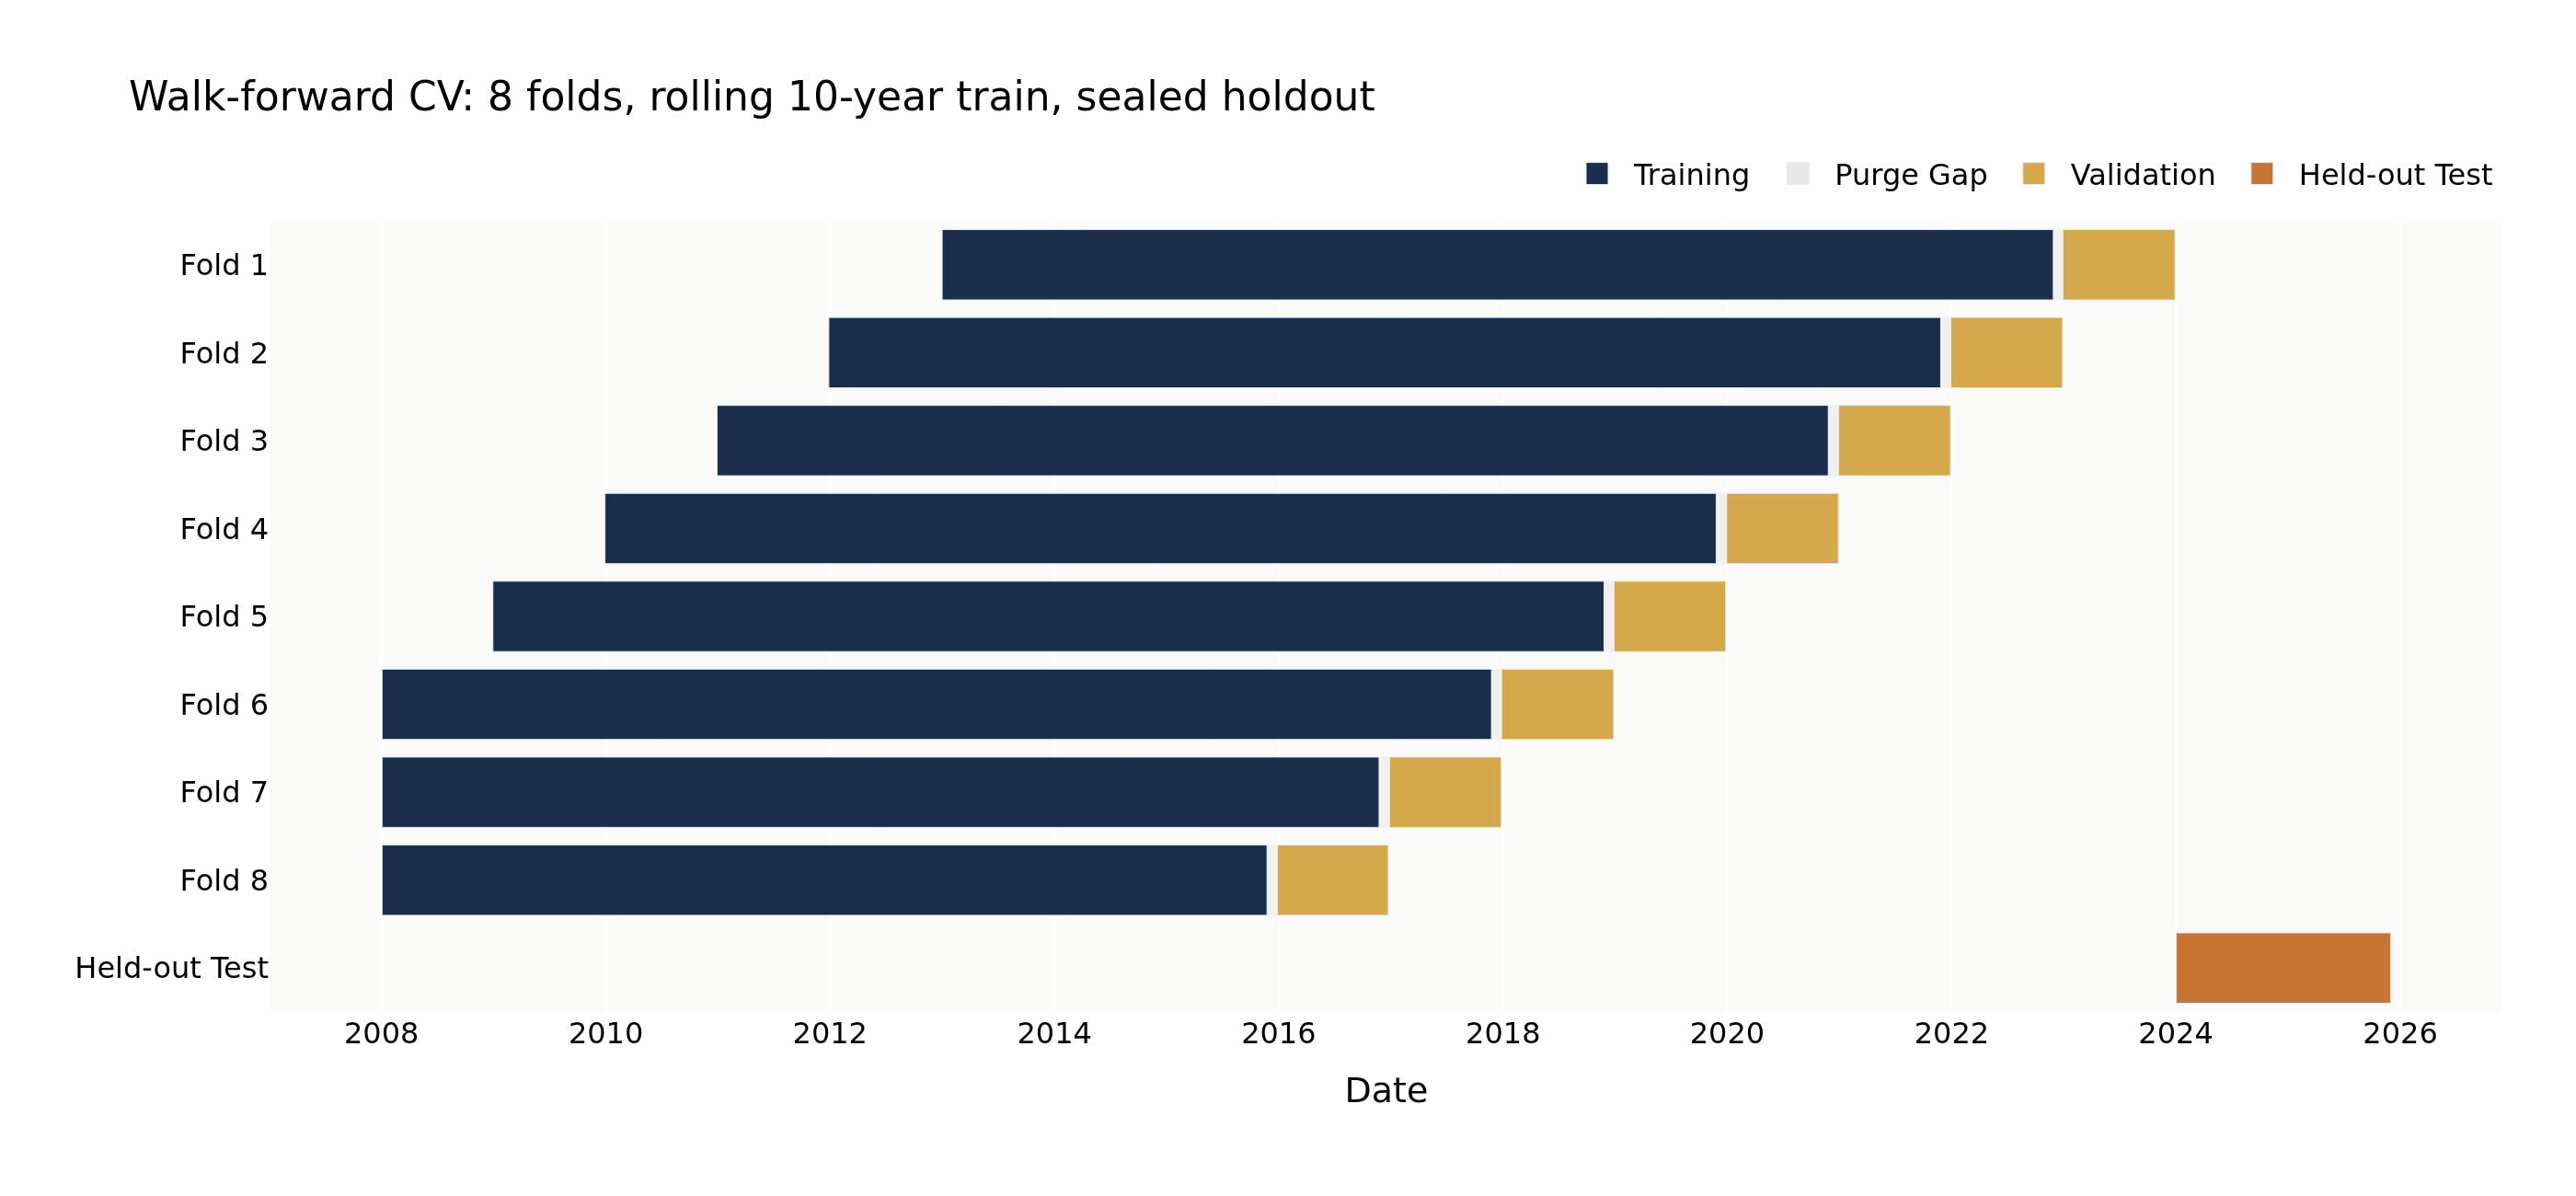

In [4]:
from pathlib import Path

from IPython.display import Image
from ml4t.diagnostic.visualization.cv_plots import plot_cv_folds

FIGURE_DIR = Path("../figures")
FIGURE_DIR.mkdir(exist_ok=True)

# ml4t-diagnostic ships several themes. "presentation" is the high-contrast one; the
# "print" theme is grayscale, which collapses a two-series chart into two lines nobody
# can tell apart from the back of a room.
THEME = "presentation"


def show(fig, filename, width=1400, height=650):
    """Write a Plotly figure to figures/ and display it as a static image.

    Plotly returns a JSON mime bundle that only draws where a live Plotly frontend is
    loaded, so a saved notebook shows blank cells on GitHub and offline. Displaying the
    exported PNG keeps every chart visible in the committed notebook and in a live run.
    """
    path = FIGURE_DIR / filename
    fig.write_image(path, width=width, height=height, scale=2)
    return Image(filename=str(path), width=width)


def as_date_axis(fig):
    """Work around ml4t-diagnostic<=0.1.0b25's static export of plot_cv_folds.

    kaleido>=1.0's serializer rejects the pd.Timestamp values left in each bar's `base`,
    and the figure does not declare its x-axis as a date axis. Both are fixed upstream
    (diagnostic commit 390207c) but not yet released; drop this once the pin moves past b25.
    """
    fig.update_xaxes(type="date")
    for trace in fig.data:
        base = getattr(trace, "base", None)
        if base is not None:
            values = base if isinstance(base, (list, tuple)) else [base]
            trace.base = tuple(v.isoformat() if isinstance(v, pd.Timestamp) else v for v in values)
    return fig


cv_fig = plot_cv_folds(
    cv,
    X=split_frame,
    title="Walk-forward CV: 8 folds, rolling 10-year train, sealed holdout",
    theme=THEME,
)
show(as_date_axis(cv_fig), "model-cv-folds.png")

## The Information Coefficient

Every prediction above came from a fold where the model never saw that
period during training - this is out-of-sample by construction, not by
promise. We pool the eight validation folds and compute the cross-sectional
Spearman IC per date, then HAC-correct the resulting t-statistic. The two
holdout years remain sealed and do not influence this model assessment.

In [5]:
oos = pd.concat(fold_predictions).reset_index().rename(columns={"index": "timestamp"})

ic_series = cross_sectional_ic_series(
    oos,
    oos,
    pred_col="prediction",
    ret_col="fwd_ret_21d",
    date_col="timestamp",
    entity_col="symbol",
    method="spearman",
)
print(ic_series.describe())

             n_obs           ic
count  2016.000000  2016.000000
mean     93.314484     0.015207
std       3.195889     0.226101
min      86.000000    -0.752792
25%      89.000000    -0.134452
50%      95.000000     0.013348
75%      95.000000     0.173398
max      96.000000     0.686878


In [6]:
hac_stats = compute_ic_hac_stats(ic_series, ic_col="ic", label_horizon=LABEL_HORIZON)
print(hac_stats)

assert len(fold_predictions) == N_VALIDATION_FOLDS
assert hac_stats["n_periods"] == N_VALIDATION_FOLDS * 252
assert abs(hac_stats["mean_ic"] - 0.0152068) < 1e-6
assert abs(hac_stats["naive_t_stat"] - 3.0198) < 1e-4
assert abs(hac_stats["t_stat"] - 0.9418) < 1e-4
assert holdout_dates.min() >= pd.Timestamp(HOLDOUT_START, tz="UTC")
assert holdout_dates.max() <= pd.Timestamp(HOLDOUT_END, tz="UTC")

{'mean_ic': 0.01520684977220066, 'hac_se': 0.016147062727220118, 't_stat': 0.9417718893582744, 'p_value': 0.34642233143900913, 'n_periods': 2016, 'effective_lags': 20, 'naive_se': 0.005035672377891978, 'naive_t_stat': 3.019825086112238}


## Visualizing why the two t-stats disagree

The mean and the two t-stats are three numbers; this is the series behind
them. The daily points cluster into runs of several months each - visible
autocorrelation, not noise - which is exactly the dependence the naive
standard error ignores and the HAC correction accounts for.

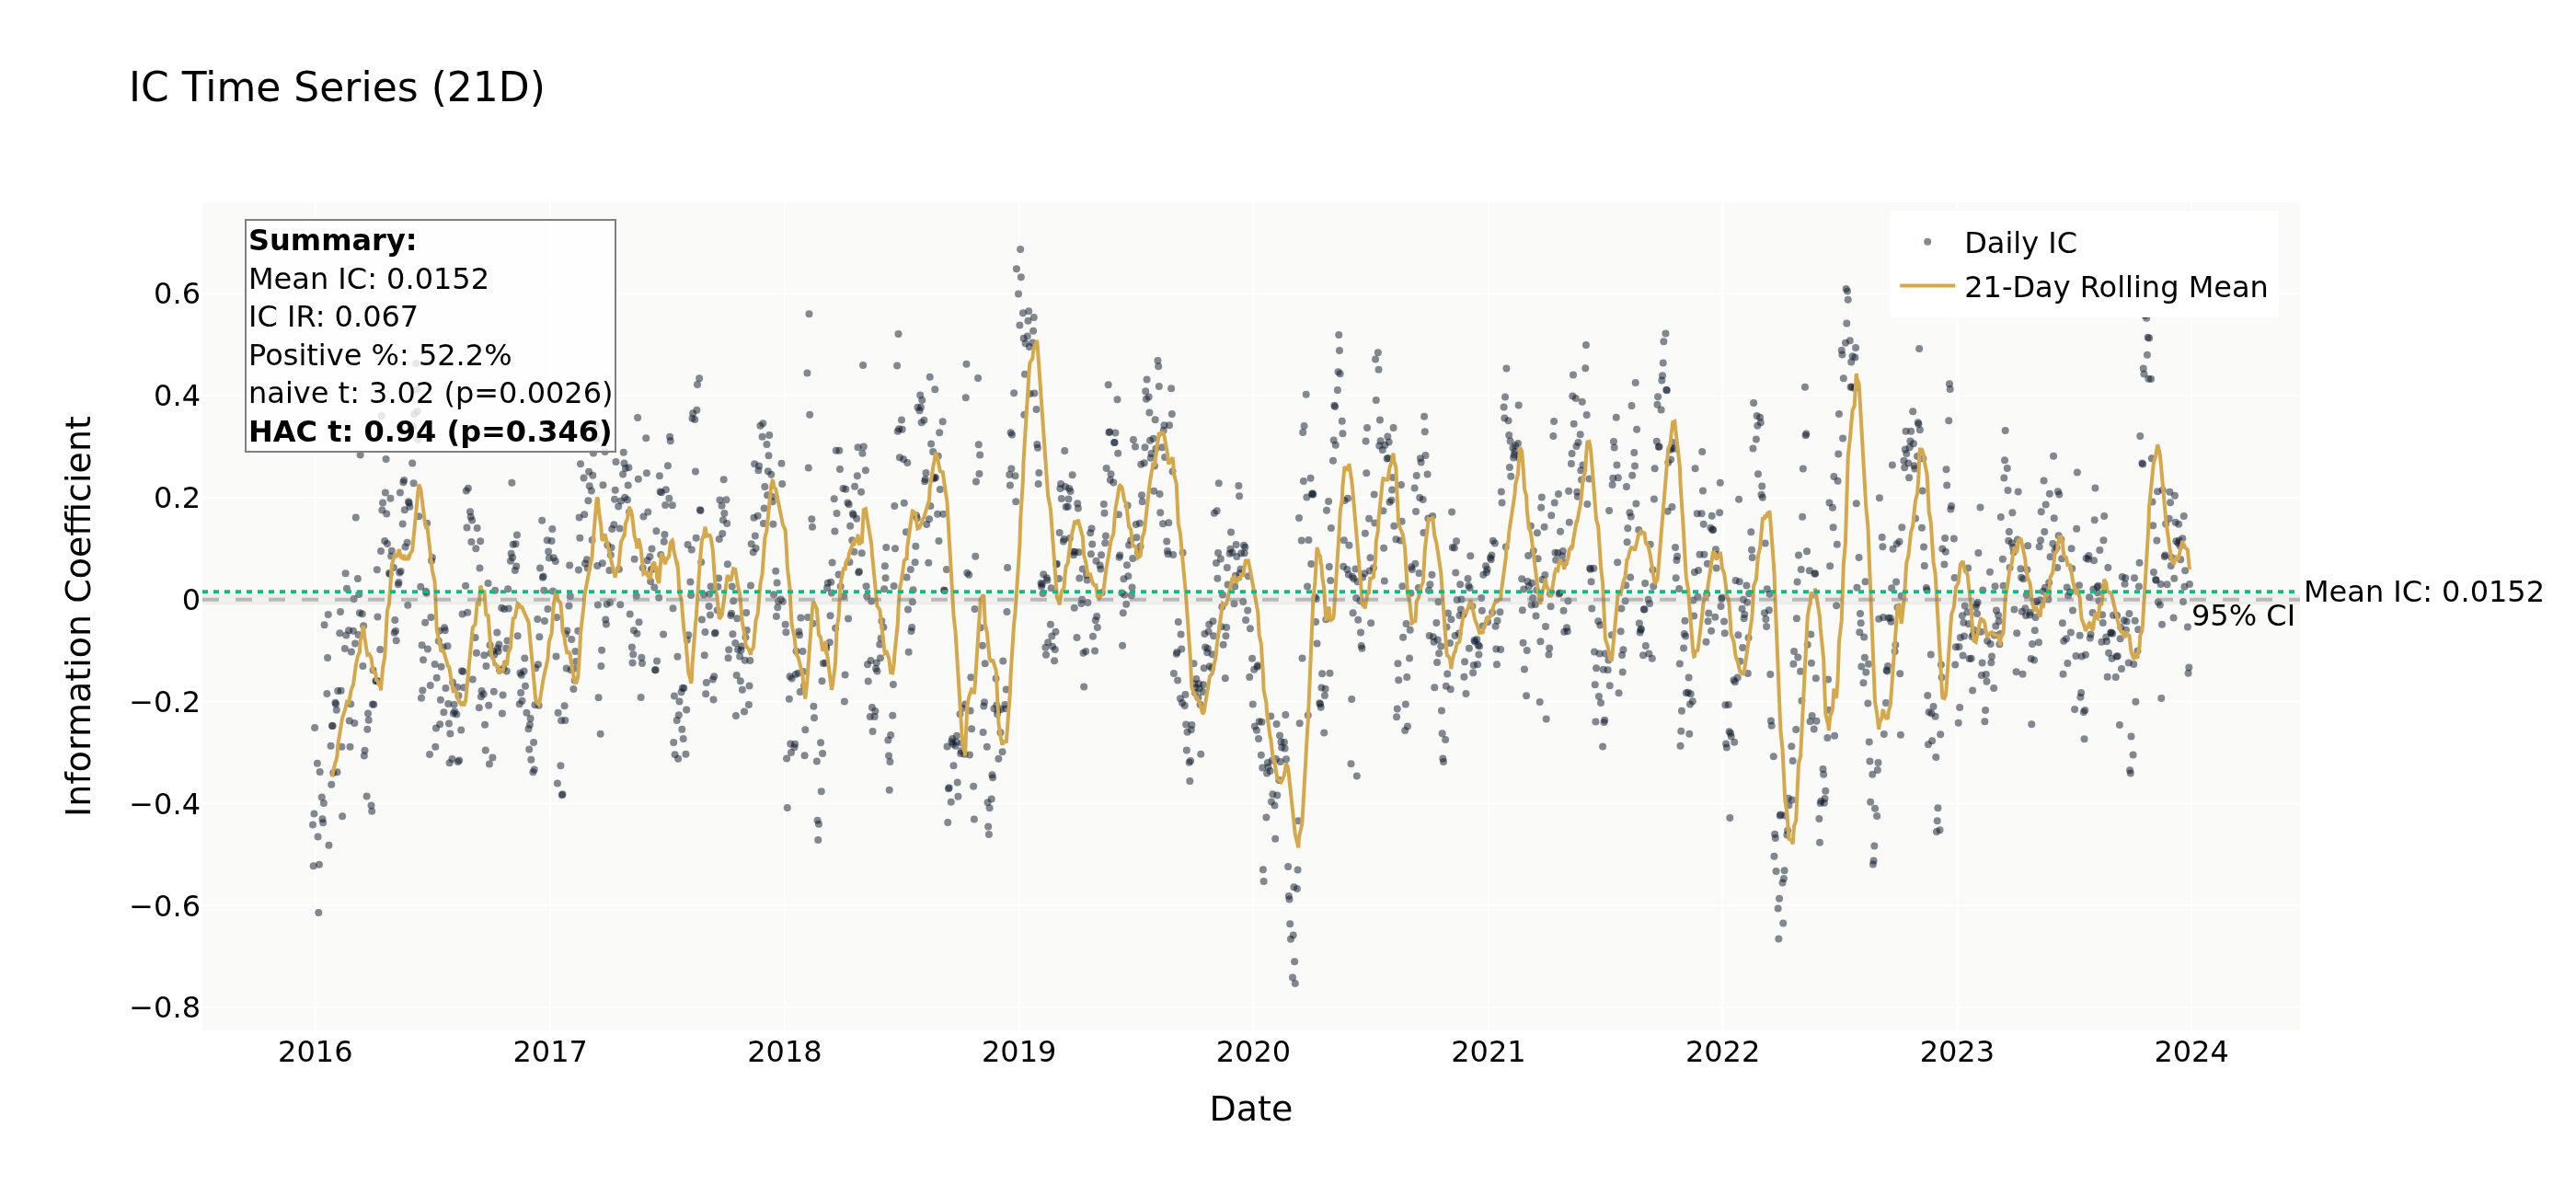

In [7]:
from ml4t.diagnostic.results.signal_results.ic import SignalICResult
from ml4t.diagnostic.visualization.signal.ic_plots import plot_ic_ts
from scipy import stats as scipy_stats

ic_values = ic_series["ic"].to_numpy().astype(float)
naive_t, naive_p = scipy_stats.ttest_1samp(ic_values, 0)
assert abs(float(naive_t) - hac_stats["naive_t_stat"]) < 1e-6

ic_result = SignalICResult(
    ic_by_date={"21D": ic_values.tolist()},
    dates=[d.isoformat() for d in ic_series["timestamp"]],
    ic_mean={"21D": float(ic_values.mean())},
    ic_std={"21D": float(ic_values.std())},
    ic_t_stat={"21D": float(naive_t)},
    ic_p_value={"21D": float(naive_p)},
    ic_positive_pct={"21D": float((ic_values > 0).mean())},
    ic_ir={"21D": float(ic_values.mean() / ic_values.std())},
    ic_t_stat_hac={"21D": hac_stats["t_stat"]},
    ic_p_value_hac={"21D": hac_stats["p_value"]},
    hac_lags_used=hac_stats["effective_lags"],
)

ic_fig = plot_ic_ts(ic_result, period="21D", rolling_window=21, show_significance=True, theme=THEME)
# The library pins "Mean" and "95% CI" labels to the right edge, where the export clips
# them, and its summary box quotes only the naive t-stat - the number this section exists
# to distrust. Widen the right margin and put the corrected statistic beside it.
ic_fig.update_layout(margin=dict(l=110, r=150, t=110, b=90))
for annotation in ic_fig.layout.annotations:
    if annotation.text and "t-stat" in annotation.text:
        annotation.text = annotation.text.replace(
            f"t-stat: {naive_t:.2f}", f"naive t: {naive_t:.2f}"
        )
        annotation.text += (
            f"<br><b>HAC t: {hac_stats['t_stat']:.2f} (p={hac_stats['p_value']:.3f})</b>"
        )

show(ic_fig, "model-ic-series.png")

`hac_stats["mean_ic"]` is the honest headline number - not the naive
t-statistic you'd get from treating each daily IC observation as
independent. Because the label is a 21-day forward return, consecutive
daily ICs share ~20 days of the same underlying return window and are
mechanically autocorrelated; the naive t-stat overstates significance.
`label_horizon=21` tells the HAC correction the minimum lag to account
for, rather than relying on order selection alone.

**Run this notebook and the two t-stats disagree with each other**: naive
≈ 3.02 (nominally "significant"), HAC ≈ 0.94 (not significant). That
gap *is* the lesson, not a bug to fix - eight simple technical features
on a monthly-rebalanced ETF panel do not reliably beat noise once the
autocorrelation induced by the overlapping 21-day label is priced in.
A model with an IC this weak has no business going anywhere near a
backtest that claims a live edge; block 8 puts it through one anyway, on
purpose, to show what "weak signal, meet real costs" actually looks like.

## Does the edge concentrate in specific months?

A weak pooled IC could still be a real, month-varying effect. This
month-by-year grid shows whether that is what's actually happening, or
whether the daily series is just noisy throughout.

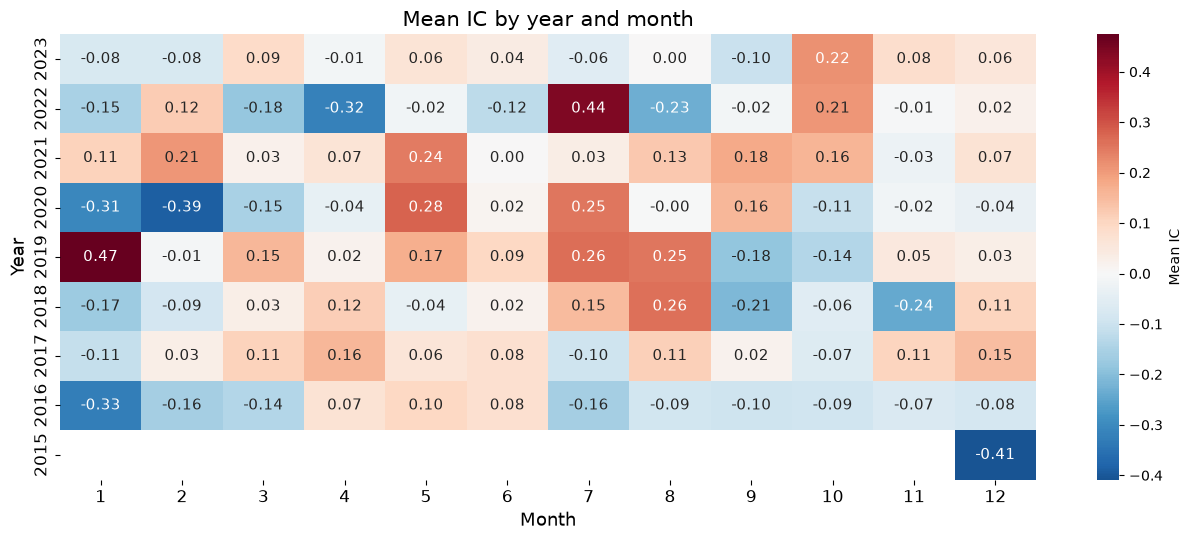

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# ml4t-diagnostic<=0.1.0b25's plot_monthly_ic_heatmap collapses every year onto a single
# row and mis-positions its cell-value annotations (confirmed independently with synthetic
# multi-year data - not a data problem here). Not yet fixed upstream, so this builds the
# same year-by-month view directly rather than shipping a broken chart.
monthly_ic = (
    ic_series.assign(year=ic_series["timestamp"].dt.year, month=ic_series["timestamp"].dt.month)
    .groupby(["year", "month"])["ic"]
    .mean()
    .unstack("month")
    .sort_index(ascending=False)
)

fig, ax = plt.subplots(figsize=(13, 5.5))
sns.heatmap(
    monthly_ic,
    cmap="RdBu_r",
    center=0,
    annot=True,
    fmt=".2f",
    annot_kws={"size": 11},
    ax=ax,
    cbar_kws={"label": "Mean IC"},
)
ax.set_xlabel("Month", fontsize=13)
ax.set_ylabel("Year", fontsize=13)
ax.set_title("Mean IC by year and month", fontsize=15)
ax.tick_params(labelsize=12)
plt.tight_layout()
fig.savefig(FIGURE_DIR / "model-ic-monthly.png", dpi=150)
plt.show()

## Feature importance

Cheap to compute, easy to over-read. Treat this as "what the last fold's
model leaned on," not as a causal or stable ranking across the full
18-year history - `13_model_analysis.py` in the full case study goes much
further (SHAP, permutation importance, stability across folds) than this
workshop has time for.

dollar_vol_rank    455
vol_63d            451
mom_252d           442
vol_21d            429
mom_126d           356
mom_63d            319
mom_21d            174
rsi_14             174
dtype: int32


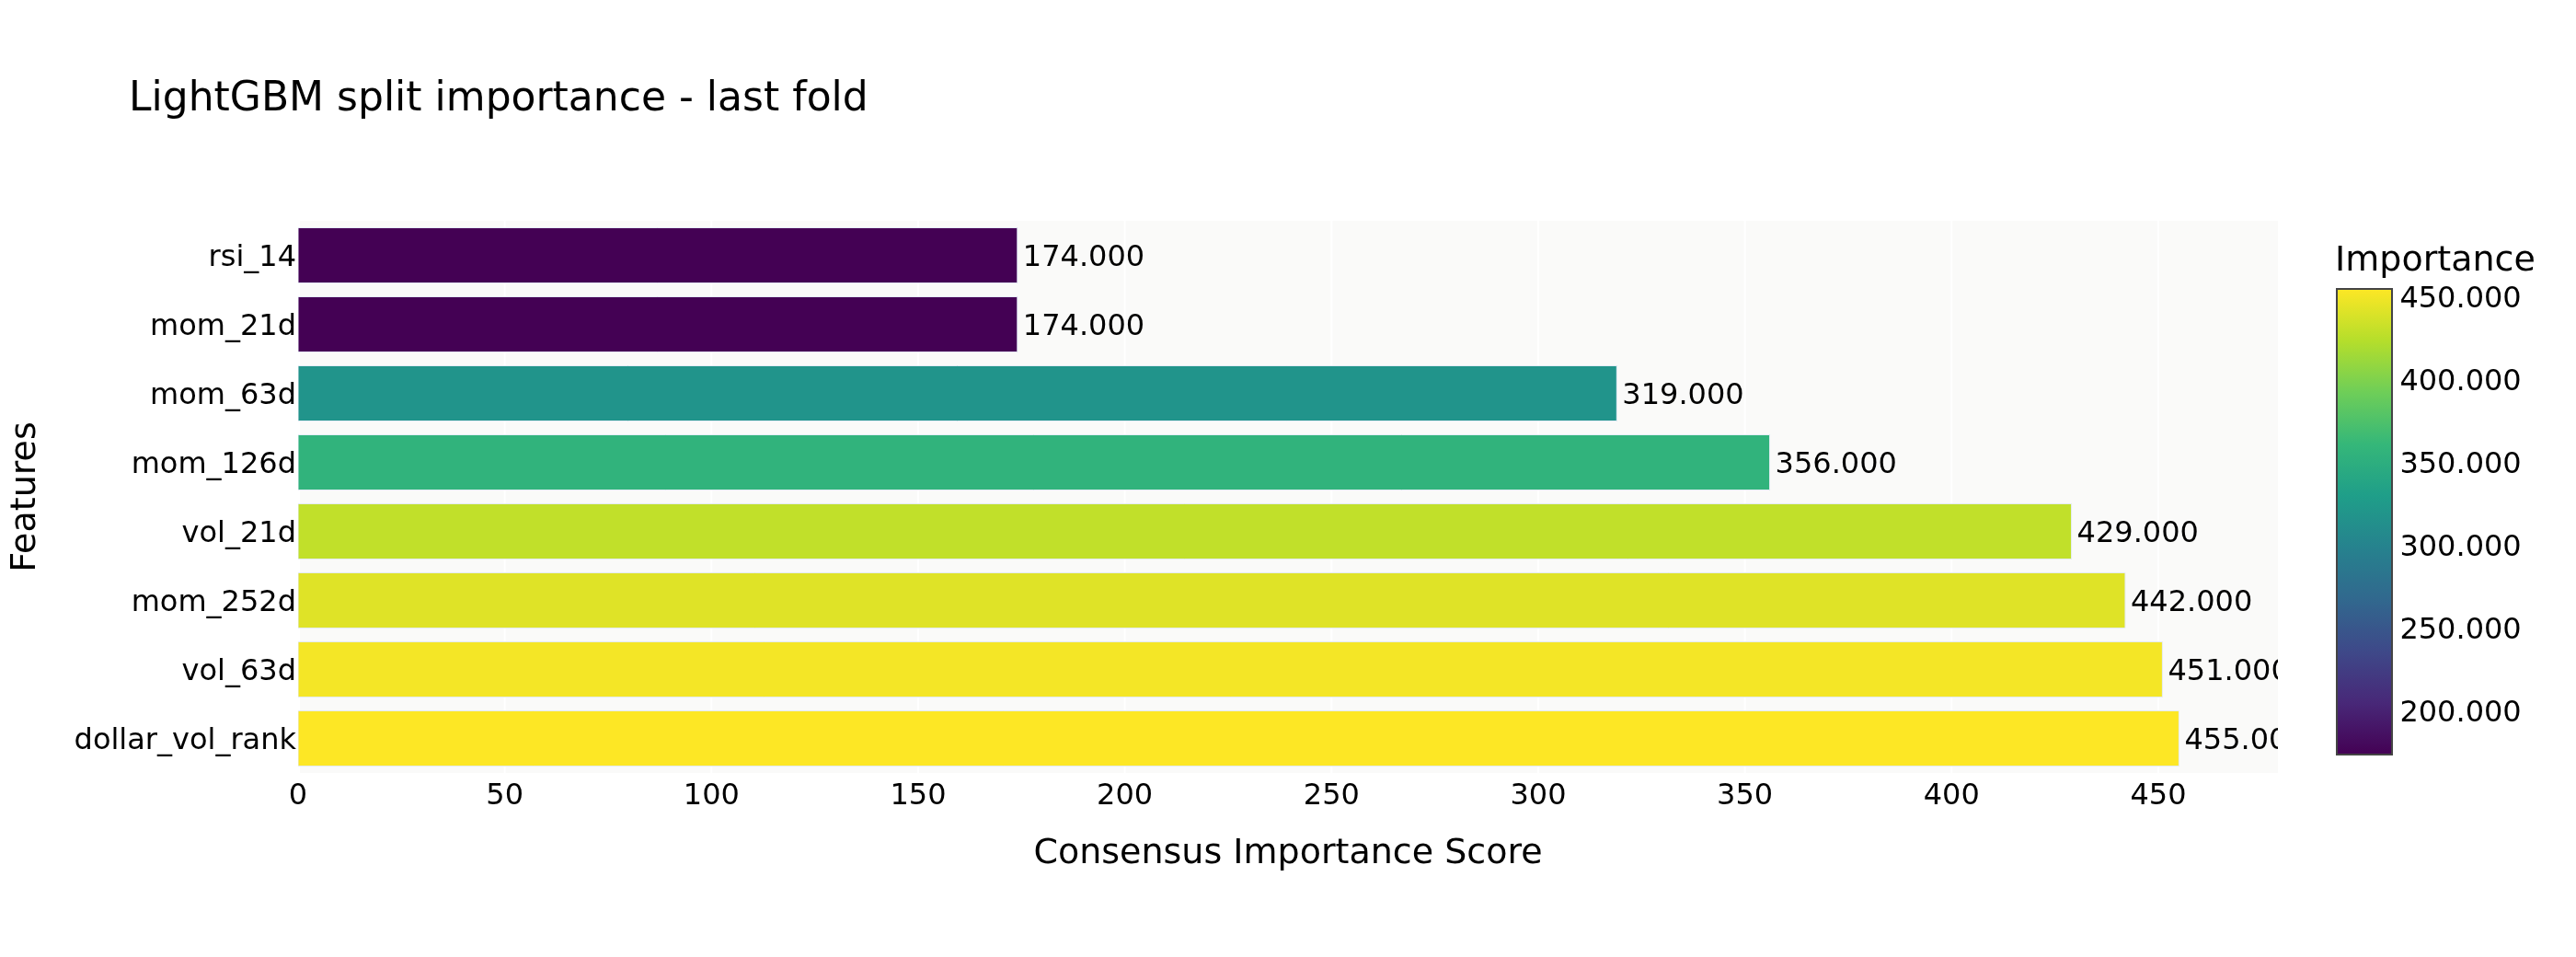

In [9]:
importance = pd.Series(model.feature_importances_, index=feature_cols).sort_values(ascending=False)
print(importance)

from ml4t.diagnostic.visualization.feature_plots import plot_importance_bar

importance_results = {
    "consensus_ranking": importance.index.tolist(),
    "method_results": {
        "mdi": {
            "importances": importance.to_numpy().tolist(),
            "feature_names": importance.index.tolist(),
        }
    },
}
importance_fig = plot_importance_bar(
    importance_results,
    title="LightGBM split importance - last fold",
    theme=THEME,
    top_n=8,
)
show(importance_fig, "model-feature-importance.png", height=520)

## Does the metric match how the strategy uses the model?

The IC scores the model's ranking of the **entire** cross-section, on every date. The
strategy does something much narrower: each month it buys the **top 10 names of 99** and
ignores the rest. Those are not the same question, and a model can do well on one while
doing nothing on the other.

`analyze_signal` is ml4t-diagnostic's entry point for exactly this. It sorts the universe
into deciles by prediction each day and reports what each decile actually earned, plus the
top-minus-bottom spread and how monotonic the relationship is.

In [10]:
from ml4t.diagnostic import analyze_signal

# The prediction frame carries UTC-aware timestamps; the price file is tz-naive. Match them
# before handing both to the analyzer.
signal_input = oos.assign(timestamp=oos["timestamp"].dt.tz_localize(None))

prices = pd.read_parquet(f"{DATA_DIR}/etf_universe.parquet")
prices["timestamp"] = pd.to_datetime(prices["timestamp"])
prices = prices[
    (prices["timestamp"] >= signal_input["timestamp"].min())
    & (prices["timestamp"] <= signal_input["timestamp"].max())
]

signal = analyze_signal(
    signal_input.rename(columns={"timestamp": "date", "symbol": "asset", "prediction": "factor"})[
        ["date", "asset", "factor"]
    ],
    prices.rename(columns={"timestamp": "date", "symbol": "asset", "close": "price"})[
        ["date", "asset", "price"]
    ],
    periods=(LABEL_HORIZON,),
    quantiles=10,
    date_col="date",
    asset_col="asset",
    factor_col="factor",
    price_col="price",
)
print(signal.summary())

Signal Analysis: 99 assets, 2016 dates
Date range: 2015-12-28 00:00:00 to 2023-12-29 00:00:00
Periods: (21,), Quantiles: 10

IC Summary:
  21D: IC=+0.0140 (t=2.68, p=0.007)*, IR=0.06, +%=51%

Spread (Top - Bottom):
  21D: -0.0004 (t=-0.47, p=0.641)

Monotonicity:
  21D: +0.115

Turnover:
  21D: 52.9%


Read the spread line first. The signal whose IC just cleared a naive significance test
produces a **top-minus-bottom decile spread of about zero, with the wrong sign**. The
monotonicity score says why: the relationship is not a staircase.

One detail worth naming before reading the chart: `analyze_signal` builds its own forward returns from the price file, so its IC of about 0.0140 differs slightly from the 0.0152 computed above against the stored label. Same model, same predictions - a different definition of the thing being predicted. That gap is small here and it is the mildest possible version of the point this section is about.

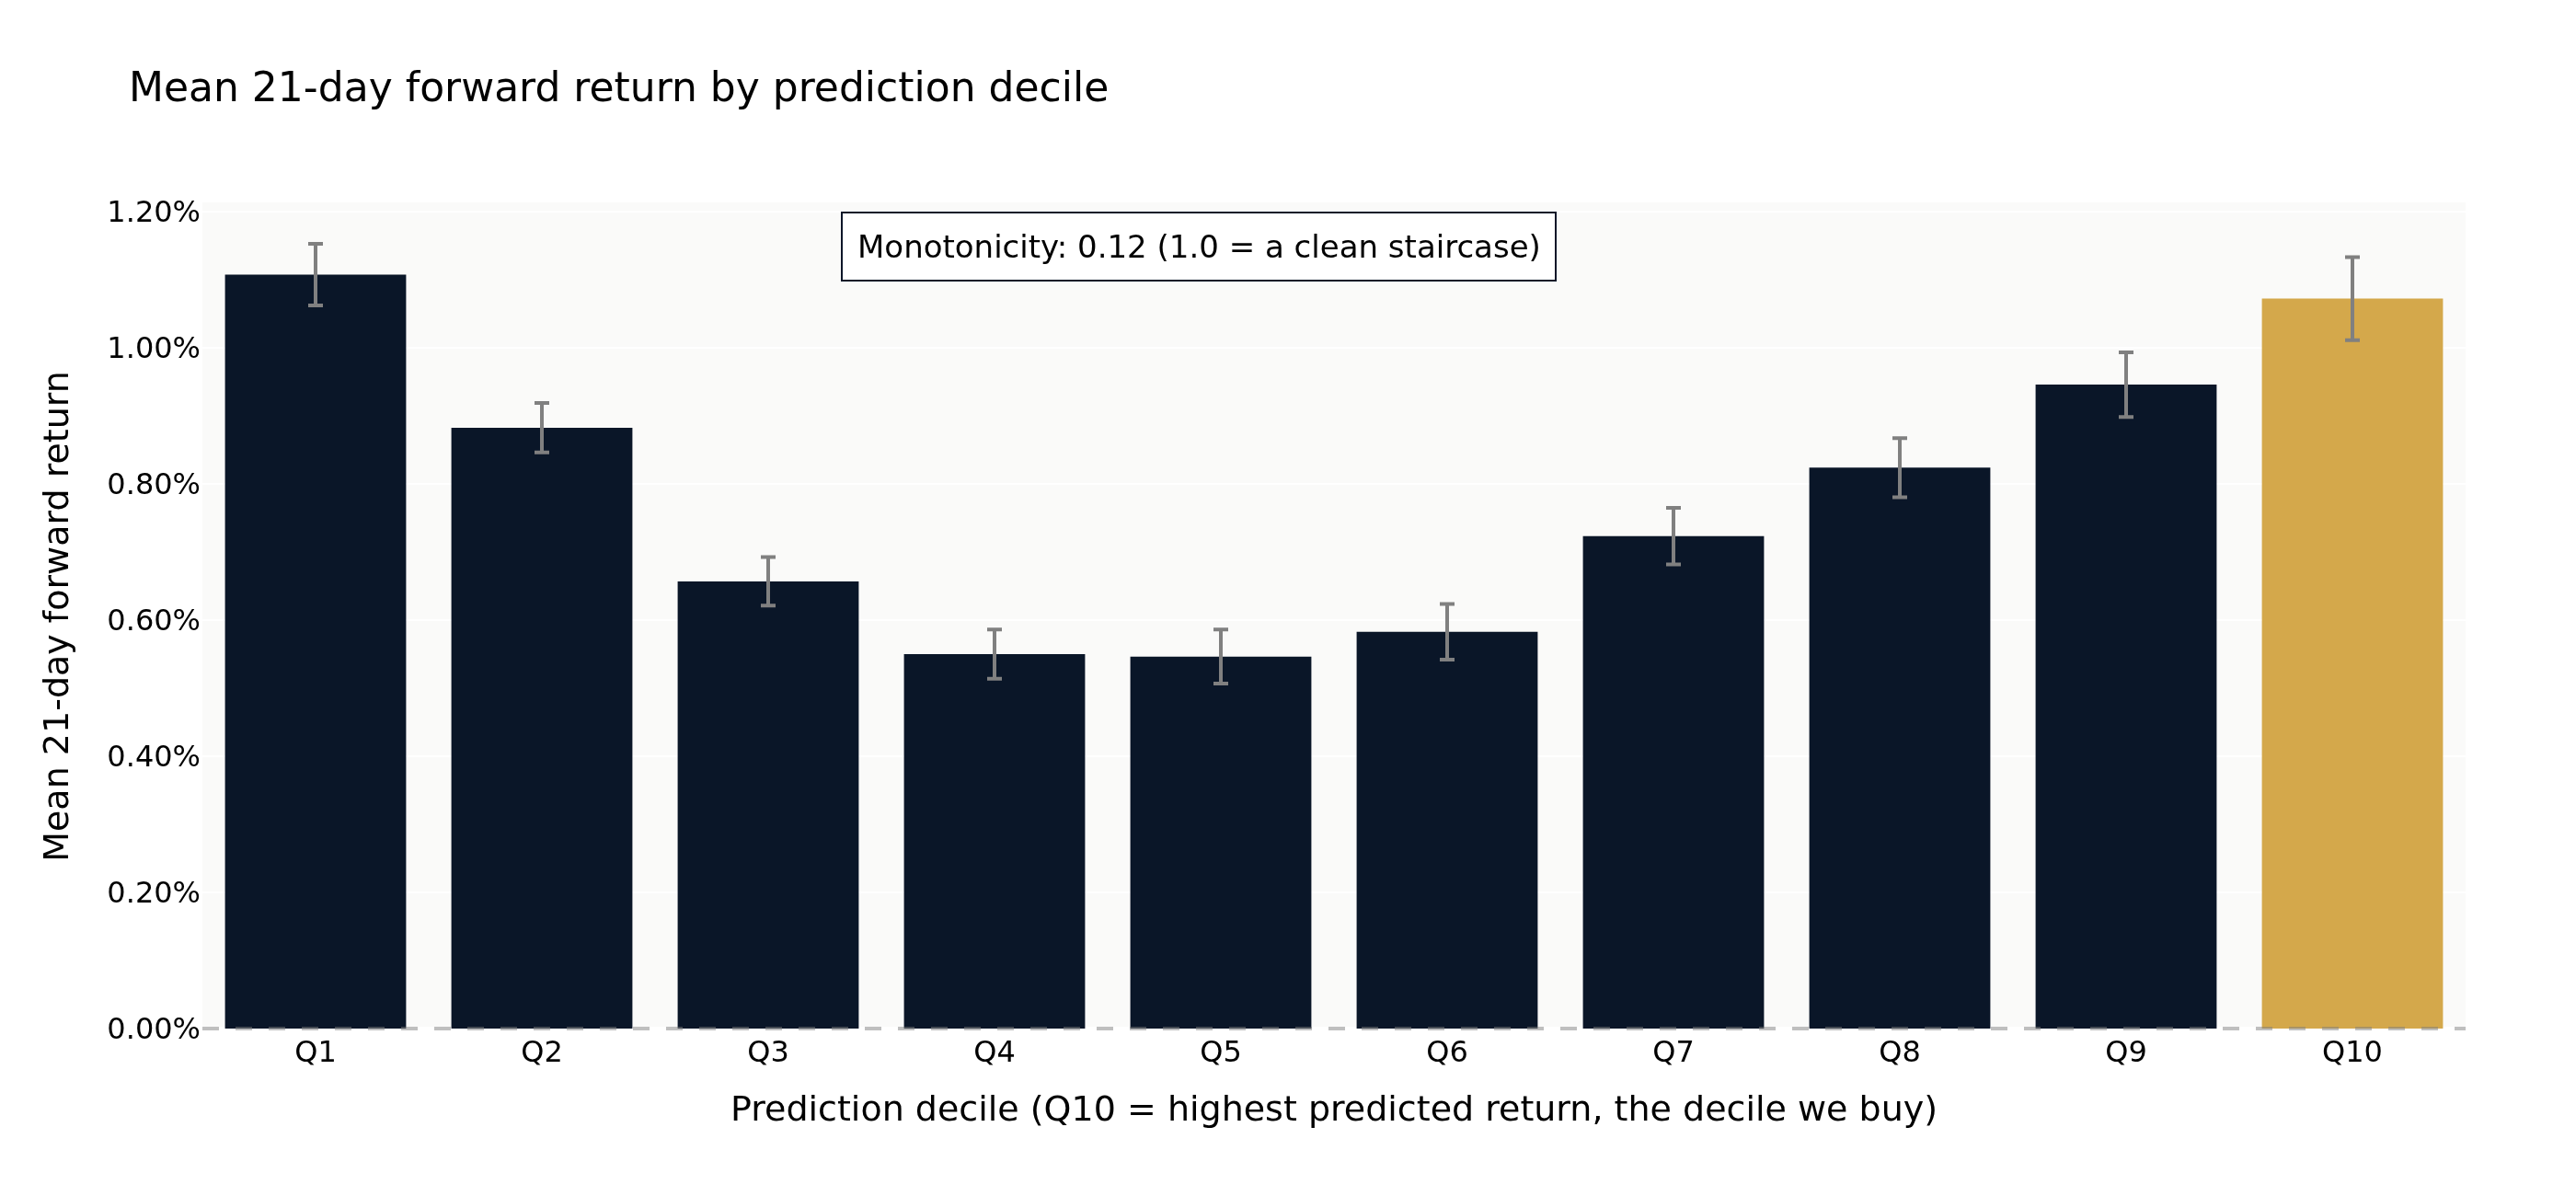

In [11]:
import plotly.graph_objects as go
from ml4t.diagnostic.visualization.signal.quantile_plots import plot_quantile_returns_bar

NAVY, GOLD = "#0a1628", "#D4A84B"

decile_fig = plot_quantile_returns_bar(
    signal.to_quantile_result(), period=f"{LABEL_HORIZON}D", theme=THEME
)
# The default red-to-green ramp reads as bad-to-good, which is exactly backwards here:
# the bottom decile earns the most. Colour only the decile the strategy actually buys.
for trace in decile_fig.data:
    if isinstance(trace, go.Bar):
        n = len(trace.x)
        trace.marker.color = [GOLD if i == n - 1 else NAVY for i in range(n)]
        trace.marker.line = dict(width=0)

decile_fig.update_layout(
    title=dict(text=f"Mean {LABEL_HORIZON}-day forward return by prediction decile"),
    yaxis_title=f"Mean {LABEL_HORIZON}-day forward return",
    xaxis_title="Prediction decile (Q10 = highest predicted return, the decile we buy)",
    margin=dict(l=110, r=60, t=110, b=90),
    showlegend=False,
)
# The library anchors its spread box inside the plot area, on top of Q10.
decile_fig.layout.annotations = ()
decile_fig.add_annotation(
    x=0.44,
    y=0.99,
    xref="paper",
    yref="paper",
    align="left",
    showarrow=False,
    bordercolor=NAVY,
    borderwidth=1,
    borderpad=8,
    bgcolor="white",
    font=dict(size=17),
    # The spread is deliberately not repeated here: the table below reports it with its
    # HAC correction, and one number quoted twice invites two different answers.
    text=f"Monotonicity: {signal.monotonicity[f'{LABEL_HORIZON}D']:.2f} (1.0 = a clean staircase)",
)

show(decile_fig, "model-decile-profile.png")

The profile is **U-shaped**. The model's *lowest* predictions earn the most, the middle
earns the least, and the top earns almost as much as the bottom. A rank correlation still
registers something, because the right half does slope upward - but a long-short book built
on this signal would hold the two highest-earning groups against each other and capture
nothing.

So put every one of these statistics through the same HAC correction the IC just failed.
Quoting a naive t-stat for one number and a corrected one for another is how a research
process fools itself.

In [12]:
deciled = oos.dropna(subset=["prediction", "fwd_ret_21d"]).copy()
deciled["decile"] = deciled.groupby("timestamp")["prediction"].transform(
    lambda s: pd.qcut(s.rank(method="first"), 10, labels=False, duplicates="drop") + 1
)
by_decile = deciled.pivot_table(
    index="timestamp", columns="decile", values="fwd_ret_21d", aggfunc="mean"
)


def hac_row(series, label):
    """HAC-correct a daily series the same way compute_ic_hac_stats corrects the IC."""
    s = series.dropna()
    stats = compute_ic_hac_stats(
        pd.DataFrame({"timestamp": s.index, "ic": s.to_numpy()}),
        ic_col="ic",
        label_horizon=LABEL_HORIZON,
    )
    return {
        "mean": s.mean(),
        "naive_t": stats["naive_t_stat"],
        "hac_t": stats["t_stat"],
        "p_value": stats["p_value"],
        "_label": label,
    }


def region_ic(frame):
    return (
        frame.groupby("timestamp")
        .apply(
            lambda g: g["prediction"].corr(g["fwd_ret_21d"], method="spearman"),
            include_groups=False,
        )
        .dropna()
    )


rows = [
    hac_row(ic_series.set_index("timestamp")["ic"], "IC, whole cross-section"),
    hac_row(by_decile[10] - by_decile[1], "Long-short spread (Q10 - Q1)"),
    hac_row(by_decile[10] - by_decile.mean(axis=1), "Top decile - universe mean"),
    hac_row(
        region_ic(deciled[(deciled["decile"] >= 4) & (deciled["decile"] <= 7)]),
        "IC within the middle deciles (Q4-Q7)",
    ),
    hac_row(
        region_ic(deciled[(deciled["decile"] <= 2) | (deciled["decile"] >= 9)]),
        "IC within the extreme deciles (Q1-Q2, Q9-Q10)",
    ),
]
hac_table = pd.DataFrame(rows).set_index("_label").rename_axis(None)
print(hac_table.round(4).to_string())

                                                 mean  naive_t   hac_t  p_value
IC, whole cross-section                        0.0152   3.0198  0.9418   0.3464
Long-short spread (Q10 - Q1)                  -0.0007  -0.8552 -0.2770   0.7818
Top decile - universe mean                     0.0023   3.6746  1.1210   0.2624
IC within the middle deciles (Q4-Q7)           0.0290   5.2451  2.0732   0.0383
IC within the extreme deciles (Q1-Q2, Q9-Q10)  0.0060   1.0197  0.3426   0.7319


Two readings matter here, and neither is visible in the headline IC.

**The strategy's own slice does earn something, but not significantly.** The top decile beat
the universe by roughly a quarter of a percent per month - which is why the backtest makes
money at all - yet once the overlap in 21-day returns is accounted for, that edge does not
separate from noise either.

**The IC's apparent strength lives where the strategy never trades.** Restricted to the
middle of the book, the ranking is twice as strong as the full-sample IC and is the only
statistic here that survives the correction. Those are the names the strategy holds no
position in. The metric is scoring work the portfolio never uses.

This is the general problem, not a quirk of this model: a learner optimizes the objective
you hand it, and a generic metric scores the whole cross-section, while the strategy
consumes a thin slice of one tail. Pick the measurement that matches the decision.

## A full-sample average hides when the model worked

One number for eight years says nothing about whether the edge was steady or arrived in a
couple of episodes. Both measures below are rolling one-year means, so each point is what a
practitioner would have seen looking back over the prior year.

rolling IC below zero on 34.8% of days
rolling top-decile edge below zero on 45.9% of days


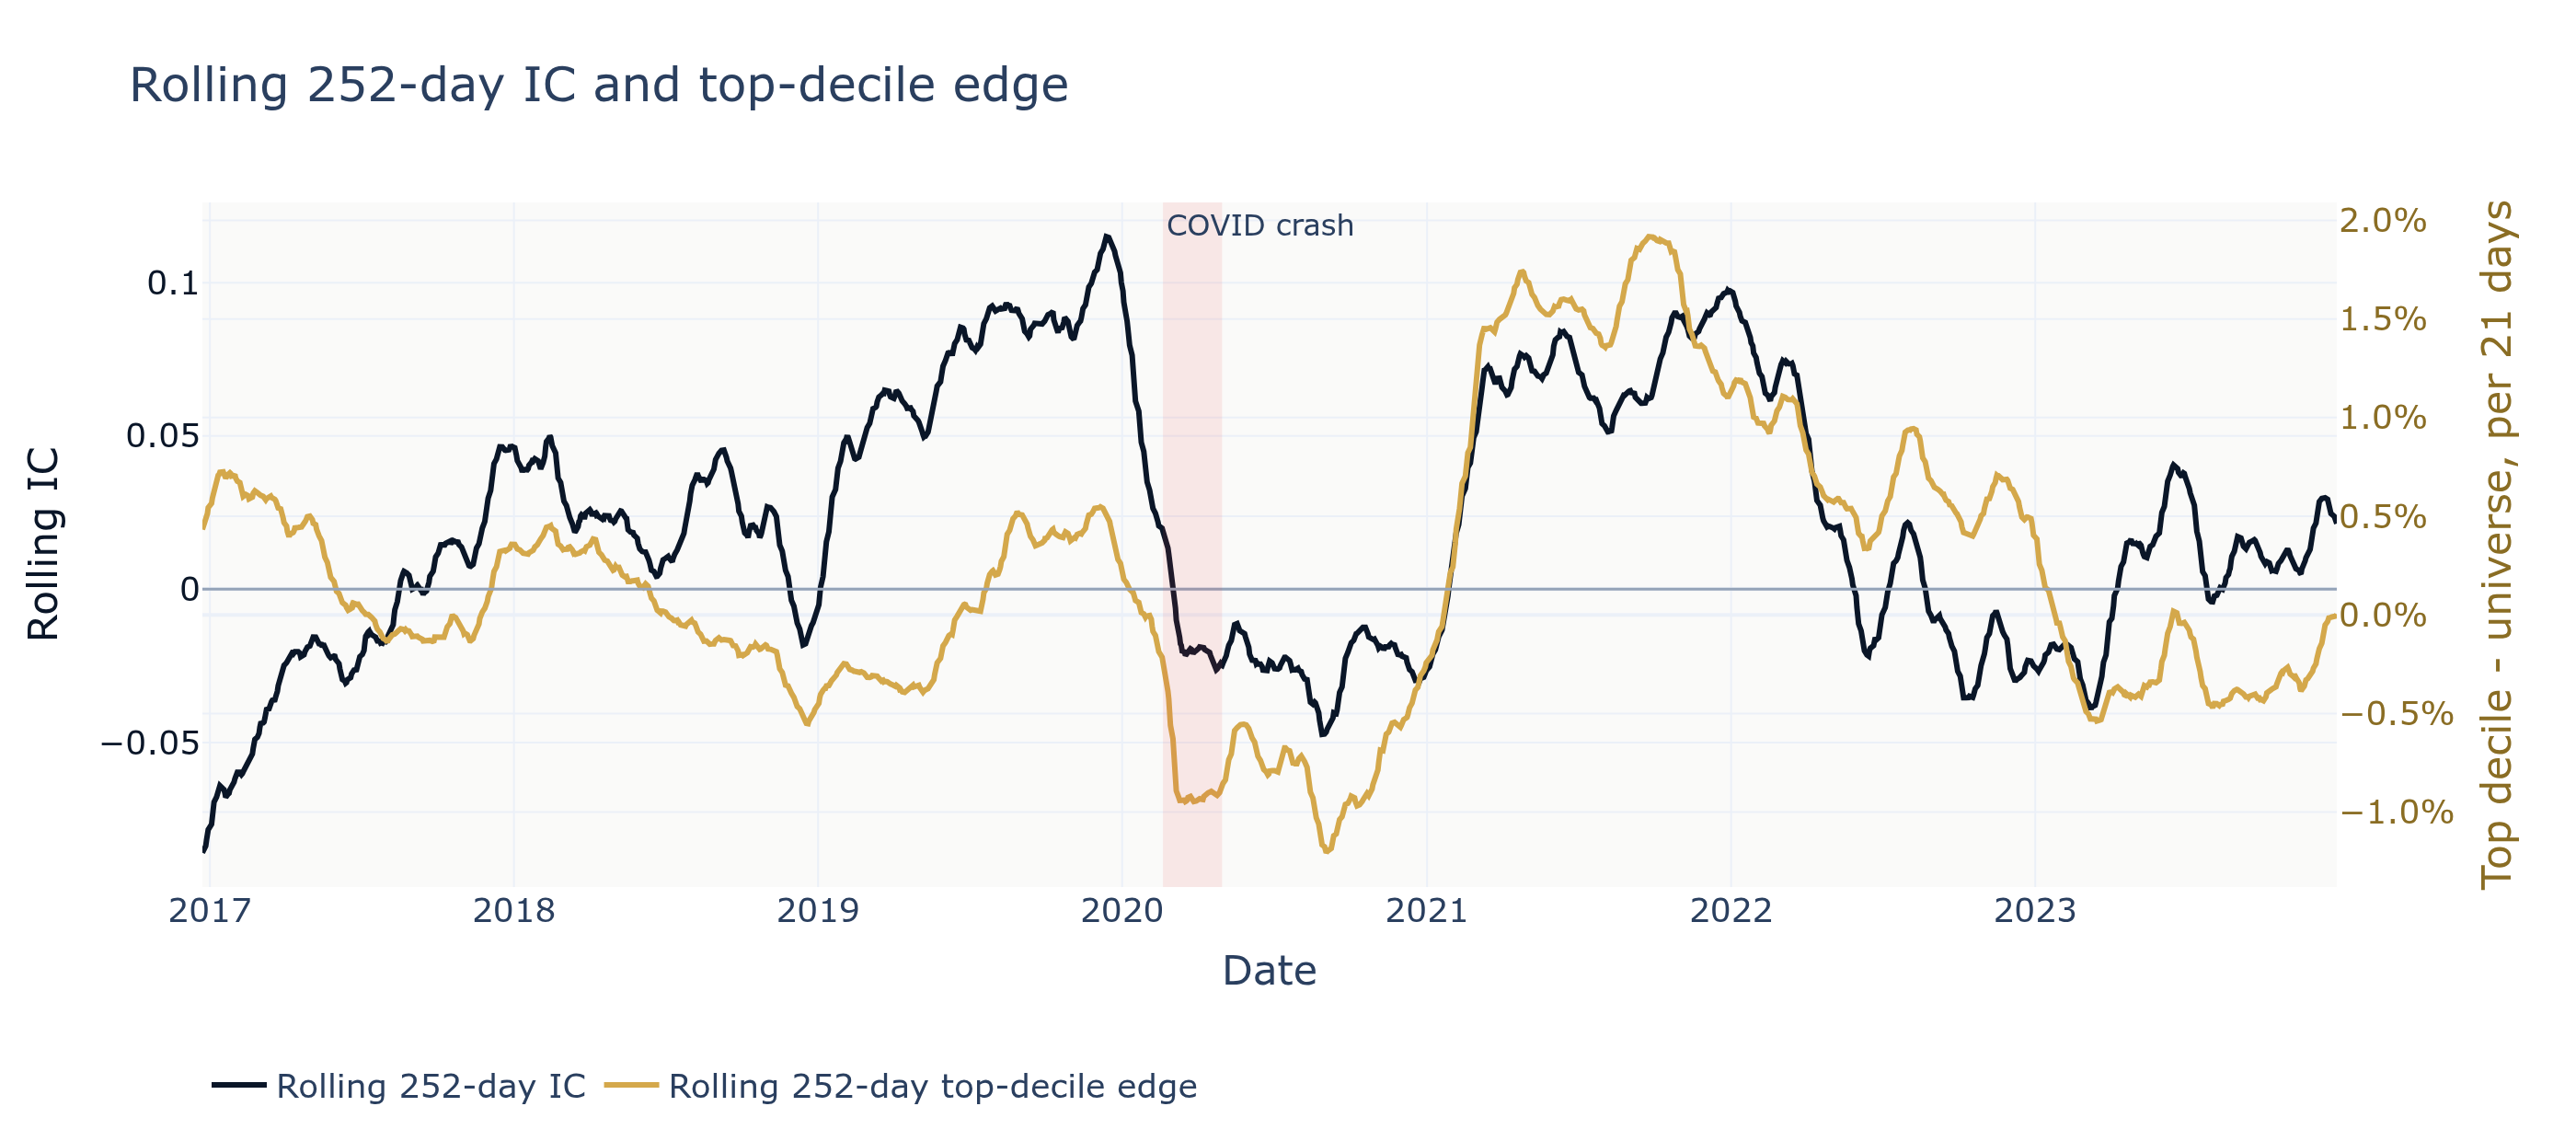

In [13]:
ROLL = 252

rolling_ic = ic_series.set_index("timestamp")["ic"].rolling(ROLL).mean().dropna()
rolling_edge = (by_decile[10] - by_decile.mean(axis=1)).rolling(ROLL).mean().dropna()
# Drop the UTC offset so the shaded date range below lands where it should.
rolling_ic.index = rolling_ic.index.tz_localize(None)
rolling_edge.index = rolling_edge.index.tz_localize(None)

stability_fig = go.Figure()
stability_fig.add_hline(y=0, line=dict(color="#94a3b8", width=1.5))
stability_fig.add_trace(
    go.Scatter(
        x=rolling_ic.index,
        y=rolling_ic,
        name=f"Rolling {ROLL}-day IC",
        line=dict(color=NAVY, width=3),
    )
)
stability_fig.add_trace(
    go.Scatter(
        x=rolling_edge.index,
        y=rolling_edge,
        name=f"Rolling {ROLL}-day top-decile edge",
        line=dict(color=GOLD, width=3),
        yaxis="y2",
    )
)
stability_fig.add_vrect(
    x0="2020-02-19",
    x1="2020-04-30",
    fillcolor="#ef4444",
    opacity=0.10,
    line_width=0,
    annotation_text="COVID crash",
    annotation_position="top left",
    annotation_font_size=16,
)
stability_fig.update_layout(
    template="plotly_white",
    title=dict(text=f"Rolling {ROLL}-day IC and top-decile edge", font=dict(size=26)),
    font=dict(size=18),
    plot_bgcolor="#FAFAF9",
    xaxis_title="Date",
    yaxis=dict(title=dict(text="Rolling IC", font=dict(color=NAVY)), tickfont=dict(color=NAVY)),
    yaxis2=dict(
        title=dict(text="Top decile - universe, per 21 days", font=dict(color="#8a6d24")),
        tickfont=dict(color="#8a6d24"),
        overlaying="y",
        side="right",
        tickformat=".1%",
    ),
    margin=dict(l=110, r=130, t=110, b=110),
    legend=dict(orientation="h", y=-0.24, x=0, font=dict(size=18)),
)

print(f"rolling IC below zero on {(rolling_ic < 0).mean():.1%} of days")
print(f"rolling top-decile edge below zero on {(rolling_edge < 0).mean():.1%} of days")
show(stability_fig, "model-rolling-stability.png", height=620)

Neither line is a stable edge. The rolling IC is negative for about a third of the sample
and the top-decile edge for close to half of it, and the two disagree for years at a stretch
- through 2019 the ranking improves while the traded slice earns nothing. The sharpest move
in both is the COVID crash, which is the honest reading of an eight-year average: it is
dominated by a handful of market episodes, not earned evenly.

**Next:** `04_backtest.ipynb` - turn these predictions into positions and
run a cost-aware backtest. Save the pooled out-of-sample predictions so
the backtest notebook doesn't need to retrain anything.

In [14]:
oos.to_parquet(f"{DATA_DIR}/oos_predictions.parquet", index=False)